В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    LogisticRegression,
    Ridge,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from ml_homework.classification import (
    add_age_group,
    compare_classification_metrics,
    compute_auroc_and_build_roc,
    get_f1_score,
    predict_and_plot,
)
from ml_homework.metrics import compare_regression_metrics
from ml_homework.paths import PROCESSED_DATA_DIR, RAW_DATA_DIR

Accuracy for Training: 89.83%
Accuracy for Validation: 89.20%
F1 score Training: 72.66%
F1 score Validation: 71.43%
AUROC for Training: 0.9304
AUROC for Validation: 0.9275


PosixPath('/Users/olharyzha/Desktop/courses/ml/lessons/my_ml_home_work/data/processed/log_reg_pipeline.joblib')

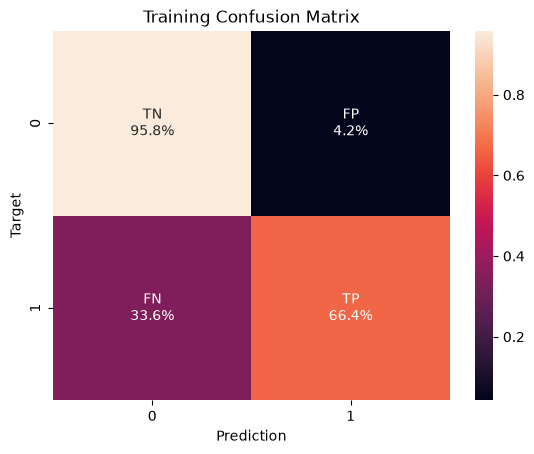

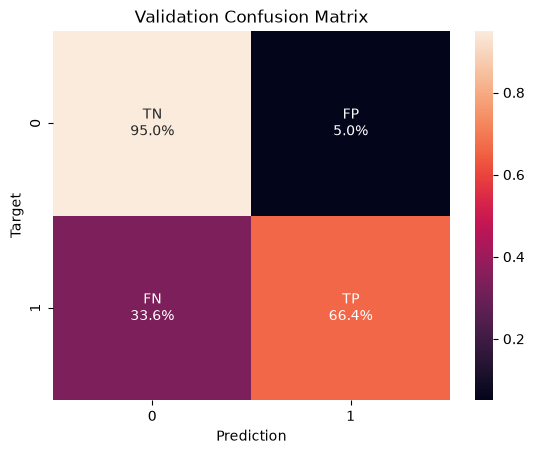

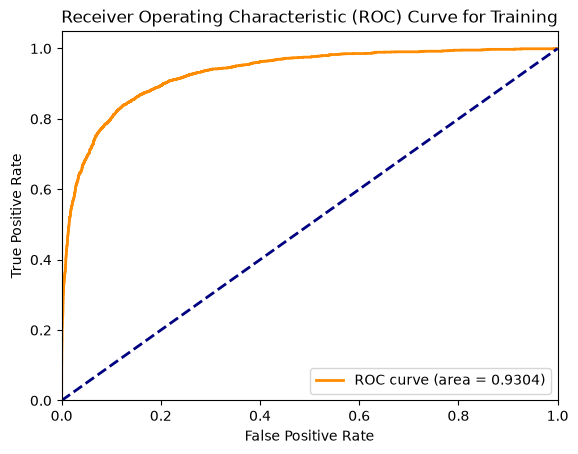

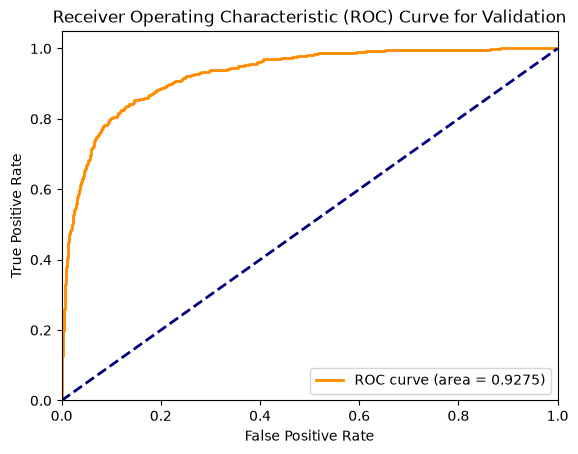

In [2]:
raw_df = add_age_group(pd.read_csv(RAW_DATA_DIR / "customer_churn/train.csv"))

target_col = "Exited"
input_cols = raw_df.columns.drop(target_col).tolist()

train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df[target_col],
)

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

identifier_cols = ["id", "CustomerId"]
discrete_cols = [
    "AgeGroup",
    "Tenure",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
]
numeric_cols = (
    train_inputs.select_dtypes(include=np.number)
    .columns.difference([*identifier_cols, *discrete_cols])
    .tolist()
)
categorical_cols = (
    train_inputs.select_dtypes(include=["str", "object"])
    .columns.difference(["Surname"])
    .tolist()
    + discrete_cols
)

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(solver="liblinear", random_state=42),
        ),
    ]
)
model_pipeline.fit(train_inputs, train_targets)

train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, "Training")
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, "Validation")

train_f1 = get_f1_score(model_pipeline, train_inputs, train_targets, "Training")
val_f1 = get_f1_score(model_pipeline, val_inputs, val_targets, "Validation")

train_auroc = compute_auroc_and_build_roc(
    model_pipeline, train_inputs, train_targets, "Training"
)
val_auroc = compute_auroc_and_build_roc(
    model_pipeline, val_inputs, val_targets, "Validation"
)

model_path = PROCESSED_DATA_DIR / "log_reg_pipeline.joblib"
joblib.dump(model_pipeline, model_path)
model_path

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Accuracy for Training: 90.08%
Accuracy for Validation: 89.27%
F1 score Training: 73.35%
F1 score Validation: 71.15%
AUROC for Training: 0.9314
AUROC for Validation: 0.9267


,Baseline,Polynomial degree 2
Train Accuracy,0.8983,0.9008
Validation Accuracy,0.8920,0.8927
Train F1,0.7266,0.7335
Validation F1,0.7143,0.7115
Train AUROC,0.9304,0.9314
Validation AUROC,0.9275,0.9267


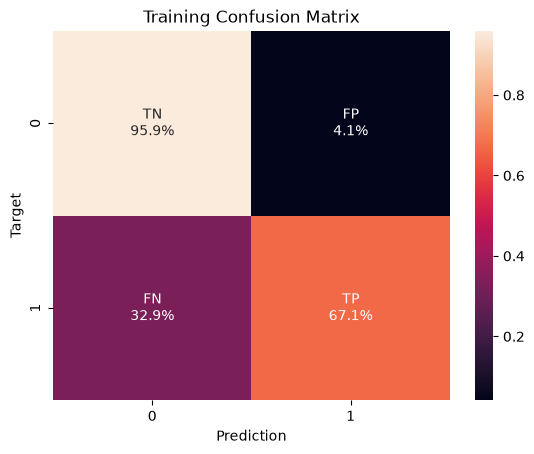

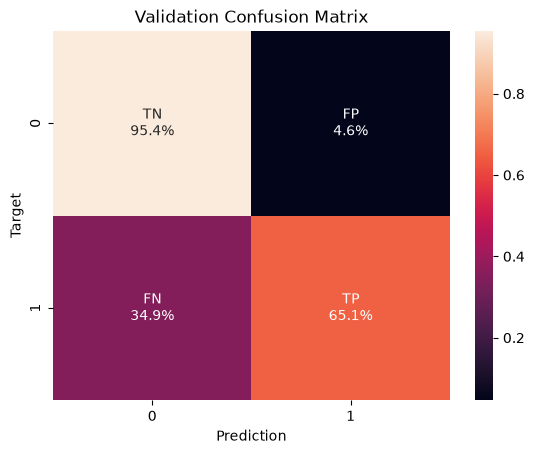

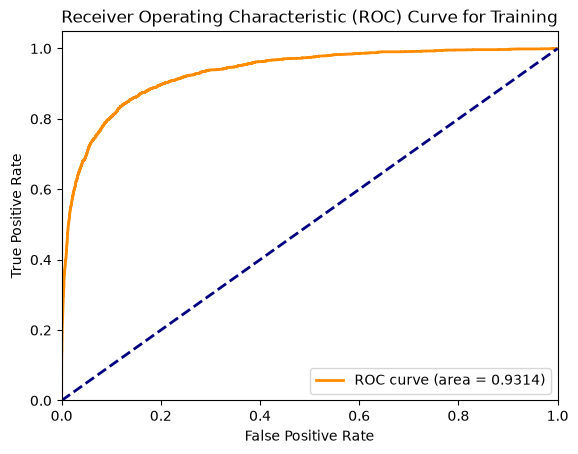

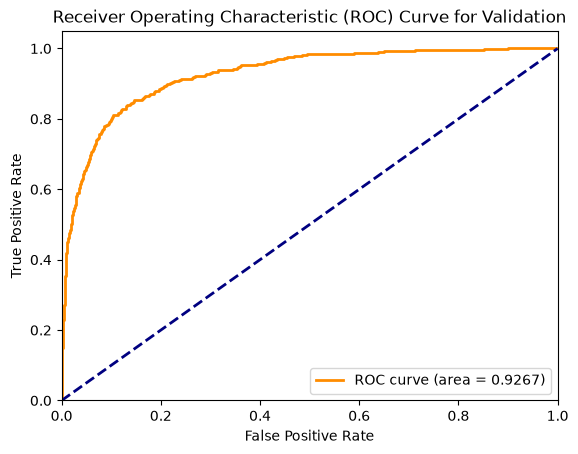

In [3]:
poly2_numeric_transformer = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
    ]
)
poly2_categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

poly2_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poly2_numeric_transformer, numeric_cols),
        ("cat", poly2_categorical_transformer, categorical_cols),
    ]
)

poly2_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", poly2_preprocessor),
        (
            "classifier",
            LogisticRegression(solver="liblinear", random_state=42),
        ),
    ]
)
poly2_model_pipeline.fit(train_inputs, train_targets)

poly2_train_preds = predict_and_plot(
    poly2_model_pipeline, train_inputs, train_targets, "Training"
)
poly2_val_preds = predict_and_plot(
    poly2_model_pipeline, val_inputs, val_targets, "Validation"
)

poly2_train_f1 = get_f1_score(
    poly2_model_pipeline, train_inputs, train_targets, "Training"
)
poly2_val_f1 = get_f1_score(poly2_model_pipeline, val_inputs, val_targets, "Validation")

poly2_train_auroc = compute_auroc_and_build_roc(
    poly2_model_pipeline, train_inputs, train_targets, "Training"
)
poly2_val_auroc = compute_auroc_and_build_roc(
    poly2_model_pipeline, val_inputs, val_targets, "Validation"
)

metrics_comparison = compare_classification_metrics(
    {
        "Baseline": model_pipeline,
        "Polynomial degree 2": poly2_model_pipeline,
    },
    train_inputs,
    train_targets,
    val_inputs,
    val_targets,
)
metrics_comparison.round(4)

Після додавання поліноміальних ознак другого степеня train-метрики трохи покращилися, але на validation модель не стала кращою: Accuracy майже не змінилася, а F1 та AUROC знизилися. Різниця між train і validation збільшилася, тому спостерігається слабке перенавчання.

Polynomial-модель не є underfit, але генералізує трохи гірше за базову Logistic Regression. Тому для прогнозування наразі краще залишити базовий pipeline без поліноміальних ознак.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Accuracy for Training: 90.15%
Accuracy for Validation: 89.20%
F1 score Training: 73.56%
F1 score Validation: 71.12%
AUROC for Training: 0.9326
AUROC for Validation: 0.9267


,Baseline,Polynomial degree 2,Polynomial degree 4
Train Accuracy,0.8983,0.9008,0.9015
Validation Accuracy,0.8920,0.8927,0.8920
Train F1,0.7266,0.7335,0.7356
Validation F1,0.7143,0.7115,0.7112
Train AUROC,0.9304,0.9314,0.9326
Validation AUROC,0.9275,0.9267,0.9267


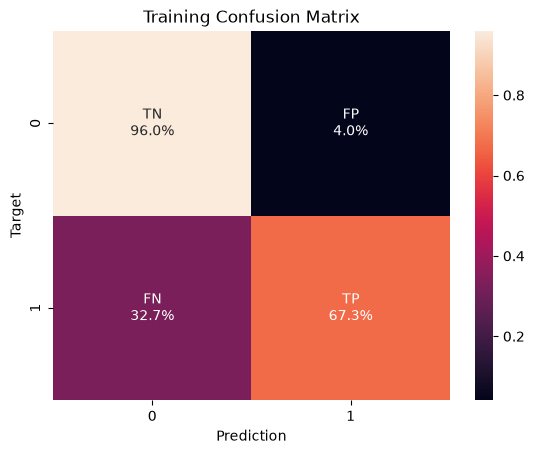

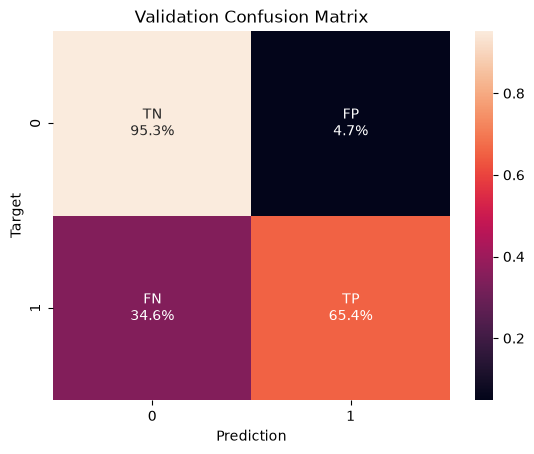

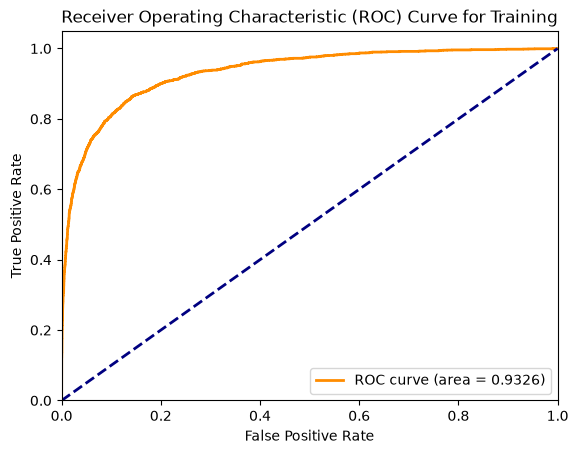

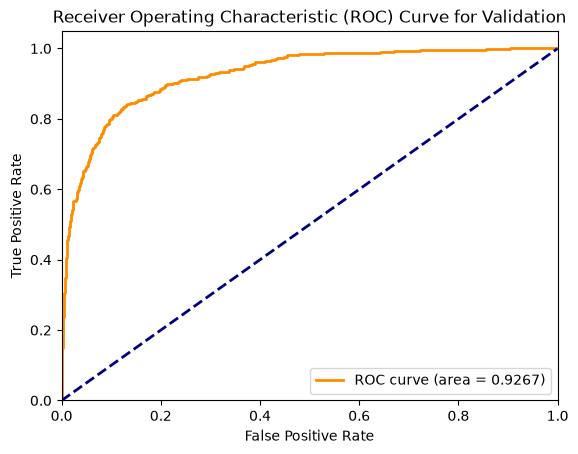

In [4]:
poly4_numeric_transformer = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=4, include_bias=False)),
        ("scaler", StandardScaler()),
    ]
)
poly4_categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

poly4_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poly4_numeric_transformer, numeric_cols),
        ("cat", poly4_categorical_transformer, categorical_cols),
    ]
)

poly4_model_pipeline = Pipeline(
    steps=[
        ("preprocessor", poly4_preprocessor),
        (
            "classifier",
            LogisticRegression(solver="liblinear", random_state=42),
        ),
    ]
)
poly4_model_pipeline.fit(train_inputs, train_targets)

poly4_train_preds = predict_and_plot(
    poly4_model_pipeline, train_inputs, train_targets, "Training"
)
poly4_val_preds = predict_and_plot(
    poly4_model_pipeline, val_inputs, val_targets, "Validation"
)

poly4_train_f1 = get_f1_score(
    poly4_model_pipeline, train_inputs, train_targets, "Training"
)
poly4_val_f1 = get_f1_score(poly4_model_pipeline, val_inputs, val_targets, "Validation")

poly4_train_auroc = compute_auroc_and_build_roc(
    poly4_model_pipeline, train_inputs, train_targets, "Training"
)
poly4_val_auroc = compute_auroc_and_build_roc(
    poly4_model_pipeline, val_inputs, val_targets, "Validation"
)

metrics_comparison = compare_classification_metrics(
    {
        "Baseline": model_pipeline,
        "Polynomial degree 2": poly2_model_pipeline,
        "Polynomial degree 4": poly4_model_pipeline,
    },
    train_inputs,
    train_targets,
    val_inputs,
    val_targets,
)
metrics_comparison.round(4)

Поліноміальні ознаки четвертого степеня трохи покращили train-метрики, але не покращили validation-результати. Validation Accuracy залишилася 0.8920, а F1 та AUROC нижчі, ніж у базової моделі. Зі збільшенням степеня поліноміальних ознак розрив між train і validation поступово зростає, що свідчить про слабке перенавчання. Найкраще генералізує базова Logistic Regression, тому саме її варто обрати серед трьох моделей.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [5]:
regression_df = pd.read_csv(RAW_DATA_DIR / "regression/regression_data.csv")

In [6]:
regression_df

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013
...,...,...,...,...,...,...
124,1.402794,0.586857,-1.401851,0.791032,-0.909387,39.626185
125,-0.288659,-0.827231,0.322719,-1.002529,-0.018513,-50.585687
126,-1.407464,-0.213447,-0.718444,0.232050,-1.448084,13.719861
127,1.353872,1.237816,-0.114540,-0.469176,-1.713135,-23.851350


In [7]:
regression_df.columns.to_list()

['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'target']

In [8]:
regression_target_col = "target"
regression_feature_cols = regression_df.columns.drop(regression_target_col).tolist()

In [9]:
train_regression_df, test_regression_df = train_test_split(
    regression_df,
    test_size=0.2,
    random_state=42,
)

In [10]:
train_regression_df.shape

(103, 6)

In [11]:
train_X = train_regression_df[regression_feature_cols].copy()
train_y = train_regression_df[regression_target_col].copy()
test_X = test_regression_df[regression_feature_cols].copy()
test_y = test_regression_df[regression_target_col].copy()

baseline_regression_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)

poly5_regression_pipeline = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=5, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)

baseline_regression_pipeline.fit(train_X, train_y)
poly5_regression_pipeline.fit(train_X, train_y)

feature_names = poly5_regression_pipeline.named_steps["poly"].get_feature_names_out(
    regression_feature_cols
)

print("Кількість ознак:", len(feature_names))

regression_metrics_comparison = compare_regression_metrics(
    {
        "Linear: original": baseline_regression_pipeline,
        "Linear: degree 5": poly5_regression_pipeline,
    },
    train_X,
    train_y,
    test_X,
    test_y,
)
regression_metrics_comparison.round(4)

Кількість ознак: 251


,Linear: original,Linear: degree 5
Train RMSE,1.0665,0.0000
Test RMSE,0.8833,12.6767
Train R²,0.9994,1.0000
Test R²,0.9997,0.9311


Модель з поліноміальними ознаками п’ятого степеня створює 251 ознаку для лише 103 тренувальних прикладів. Вона майже ідеально запам’ятовує train (RMSE ≈ 0, R² = 1), але її Test RMSE зростає з 0.8833 до 12.6767, а Test R² знижується з 0.9997 до 0.9311. Це сильне перенавчання: модель degree 5 значно гірше генералізує, тому базова лінійна регресія є кращою для цих даних.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [12]:
MAX_ITER = 50_000
DEFAULT_ALPHA = 1.0
L1_RATIO = 0.5

In [13]:
regressors = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=DEFAULT_ALPHA, max_iter=MAX_ITER),
    "Ridge": Ridge(alpha=DEFAULT_ALPHA),
    "ElasticNet": ElasticNet(
        alpha=DEFAULT_ALPHA,
        l1_ratio=L1_RATIO,
        max_iter=MAX_ITER,
    ),
}

In [14]:
regularized_pipelines = {}

for name, regressor in regressors.items():
    pipeline = Pipeline(
        steps=[
            (
                "poly",
                PolynomialFeatures(
                    degree=20,
                    include_bias=False,
                ),
            ),
            ("scaler", StandardScaler()),
            ("regressor", regressor),
        ]
    )

    pipeline.fit(train_X, train_y)
    regularized_pipelines[name] = pipeline

In [15]:
models_to_compare = {
    "Linear: original": baseline_regression_pipeline,
    "Linear: degree 5": poly5_regression_pipeline,
    "Linear: degree 20": regularized_pipelines["Linear Regression"],
    "Lasso: degree 20": regularized_pipelines["Lasso"],
    "Ridge: degree 20": regularized_pipelines["Ridge"],
    "ElasticNet: degree 20": regularized_pipelines["ElasticNet"],
}

regularization_comparison = compare_regression_metrics(
    models_to_compare,
    train_X,
    train_y,
    test_X,
    test_y,
)

regularization_comparison.T.round(4)

,Train RMSE,Test RMSE,Train R²,Test R²
Linear: original,1.0665,0.8833,0.9994,0.9997
Linear: degree 5,0.0000,12.6767,1.0000,0.9311
Linear: degree 20,0.0000,65.3912,1.0000,-0.8328
Lasso: degree 20,1.4794,1.3921,0.9989,0.9992
Ridge: degree 20,1.0537,27.7976,0.9994,0.6688
ElasticNet: degree 20,12.0443,20.6240,0.9255,0.8177


Серед моделей з поліноміальними ознаками 20-го степеня найкраще спрацювала Lasso: результати на train і test майже однакові, а R² близький до 1. Регуляризація допомогла моделі не перенавчитися на великій кількості ознак. Однак найкращою загалом залишається проста LinearRegression без поліноміальних ознак, у якої Test RMSE дорівнює 0.8833. Отже, ускладнення моделі в цьому випадку не дало кращого результату.